#**-- Sistema de Visão Computacional com YOLOv5 --**

## 📌**Introdução**

A visão computacional é uma área da Inteligência Artificial que permite que sistemas interpretem e compreendam imagens.

Neste projeto, foi desenvolvido um modelo de detecção de objetos utilizando o algoritmo YOLOv5.


---
---
## 🎯 **Objetivo**
O objetivo foi treinar um modelo capaz de detectar e classificar bananas e laranjas em imagens, além de buscar analisar o impacto da variação no número de épocas (número de vezes em que o modelo é executado) no processo de treinamento.

---
---
## 📂 **Dataset**
O dataset utilizado foi composto por 80 imagens no total, sendo:

- 40 imagens de bananas 🍌
- 40 imagens de laranjas 🍊

As imagens foram divididas da seguinte forma:

- Treinamento: 32 imagens de cada classe (64 no total)
- Validação: 4 imagens de cada classe (8 no total)
- Teste: 4 imagens de cada classe (8 no total)

E a organização foi em diretórios separados (treino, validação e teste).

---
---
## 🏷️ **Labels (rotulação) das Imagens**
A rotulação das imagens foi através da ferramenta ***MakeSense.ai***, duas classes (banana e laranja) e o método de bounding box (quadrados/retângulos) para enquadramento dos objetos.

---
---
## 🔍 Validação do Modelo

Durante o treinamento, foi utilizado o conjunto de validação (composto por 8 imagens totais).

Esse conjunto permitiu monitorar o desempenho do modelo ao longo das épocas, evitando overfitting e garantindo que o modelo generalizasse bem para dados não vistos durante o treinamento.

Observou-se que, com o aumento do número de épocas, houve melhora nas métricas também no conjunto de validação.

---
---

## 🧠 **Treinamento do Modelo**
A priori, foi utilizado 30 e 60 épocas, contudo, o número mais elevado demonstrou uma maior possibilidade de overfitting, sendo assim, foi feito um ajuste para 30 e 45 épocas, sendo eles os melhores resultados.

Abaixo, será realizado todo o processo de treinamento, e nele consiste toda a estruturação do código com seus respectivos comentários. Porém, antes de reproduzi-lo, será necessário o download do arquivo e então o upload dele em seu Google Drive.

**Link do dataset para download:** https://drive.google.com/drive/folders/1ONYyRtnXcSFOjG0KqdnXbfA3P3xczKVv?usp=sharing

Após realizar esse passo, ao iniciar a execução do treinamento, será necessário conceder a permissão ao Google Colab para que ele receba acesso ao seu Google Drive para conseguir receber as informações do dataset.



In [55]:
#################################
## --INICIANDO O TREINAMENTO-- ##
#################################


#Importação e solicitação do acesso ao drive.
from google.colab import drive
drive.mount("/content/drive")

import os

from IPython.display import Image as DisplayImage, display

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [56]:
#Verificações para garantir que a pasta está sendo selecionada corretamente.
!ls /content/drive/MyDrive/dataset_fase6/train/images

print("")

!ls /content/drive/MyDrive/dataset_fase6/train/labels

ls: cannot access '/content/drive/MyDrive/dataset_fase6/train/images': No such file or directory

ls: cannot access '/content/drive/MyDrive/dataset_fase6/train/labels': No such file or directory


In [57]:
#Download do repositório YOLOv5, acesso e instalação dos arquivos necessários.
!git clone https://github.com/ultralytics/yolov5
%cd yolov5
!pip install -r requirements.txt

Cloning into 'yolov5'...
remote: Enumerating objects: 17898, done.
remote: Counting objects: 100% (61/61), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 17898 (delta 41), reused 14 (delta 13), pack-reused 17837 (from 5)
Receiving objects: 100% (17898/17898), 17.03 MiB | 24.52 MiB/s, done.
Resolving deltas: 100% (12179/12179), done.
/content/yolov5/yolov5/yolov5/yolov5/yolov5


In [58]:
#Criação do arquivo no Colab
%%writefile data.yaml
train: /content/drive/MyDrive/dataset_fase6/train/images
val: /content/drive/MyDrive/dataset_fase6/val/images
test: /content/drive/MyDrive/dataset_fase6/test/images

#Quantidade de classe
nc: 2
#Ordem das classe — A alteração fará o modelo trocar os nomes nas previsões.
names: ["banana", "laranja"]

Writing data.yaml


In [ ]:
#Conversão das imagens para jpg
from PIL import Image
pasta = "/content/drive/MyDrive/dataset_fase6/train/images"

for file in os.listdir(pasta):
    path = os.path.join(pasta, file)

    try:
        img = Image.open(path)
        new_path = os.path.splitext(path)[0] + ".jpg"

        img.convert("RGB").save(new_path, "JPEG")

        if path != new_path:
            os.remove(path)

    except Exception as e:
        print(f"Erro em {file}: {e}")

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [60]:
#Treinamento — 640 pixels, 16 imagens por vez, 30 vezes e carregamento de um modelo pequeno pré-treinado para um transfer learning.
!python train.py --img 640 --batch 16 --epochs 30 --data data.yaml --weights yolov5s.pt

wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2026-04-28 20:09:11.561168: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777406951.644105   91357 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777406951.669412   91357 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777406951.803136   91357 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777406951.803222   91357 computation_placer.cc:177] computation placer already registere

In [61]:
#Treinamento — 640 pixels, 16 imagens por vez, 45 vezes e carregamento de um modelo pequeno pré-treinado para um transfer learning.
!python train.py --img 640 --batch 16 --epochs 45 --data data.yaml --weights yolov5s.pt

wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2026-04-28 20:51:16.976236: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777409477.014980  101601 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777409477.029002  101601 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777409477.081352  101601 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777409477.081421  101601 computation_placer.cc:177] computation placer already registere

In [62]:
#Listagem das pastas onde os treinamentos estão salvos
!ls runs/train

exp  exp2


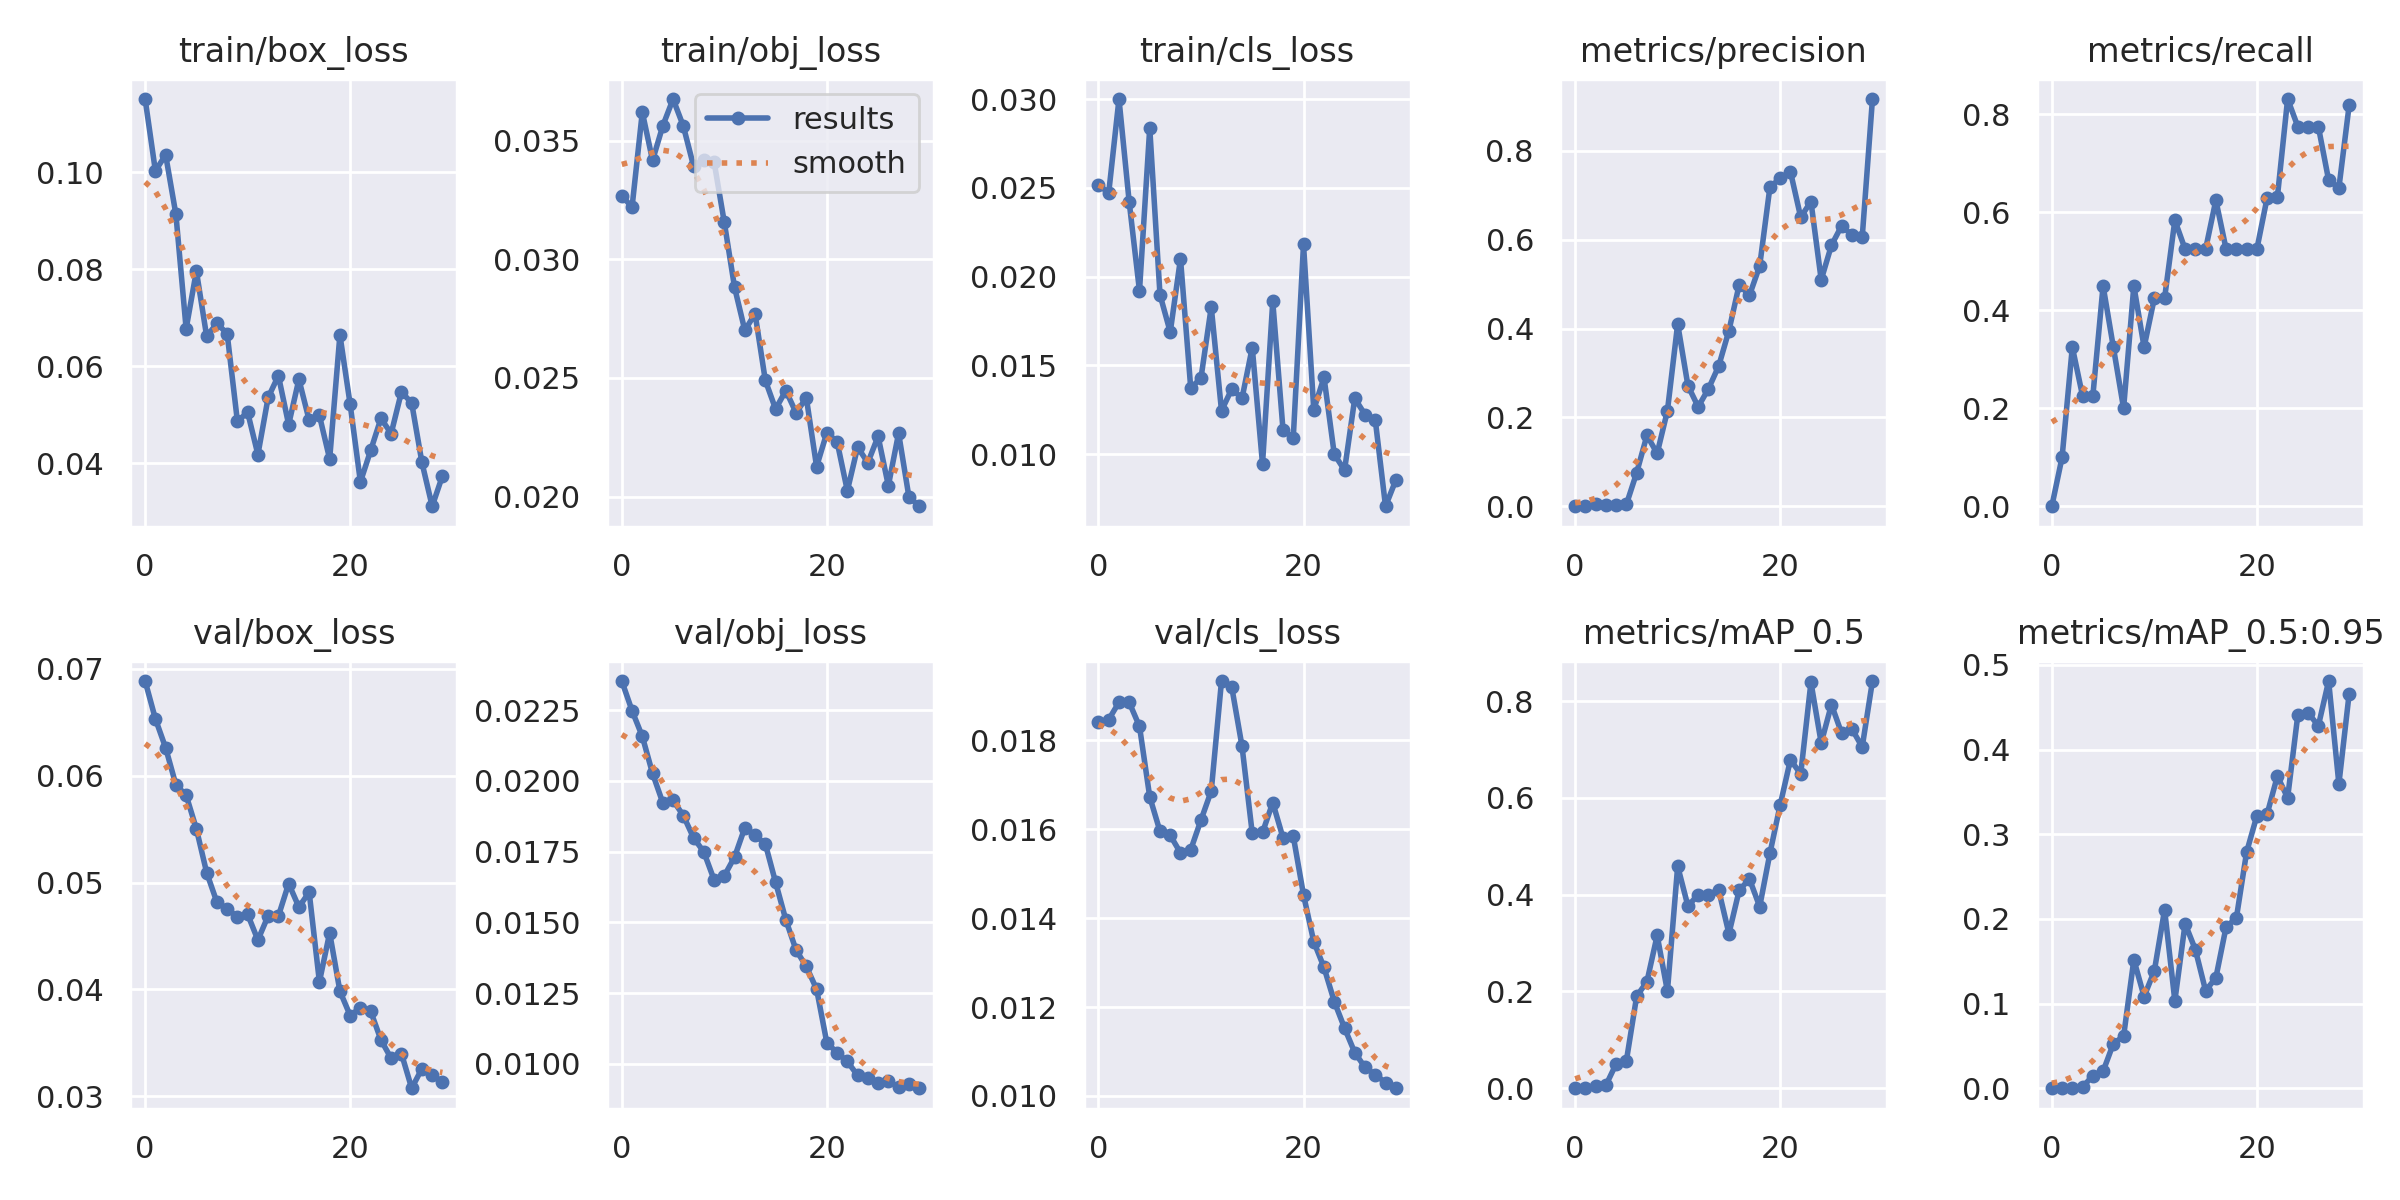

In [63]:
#Construção do gráfico de representação do experimento 1
display(DisplayImage(filename='runs/train/exp/results.png'))

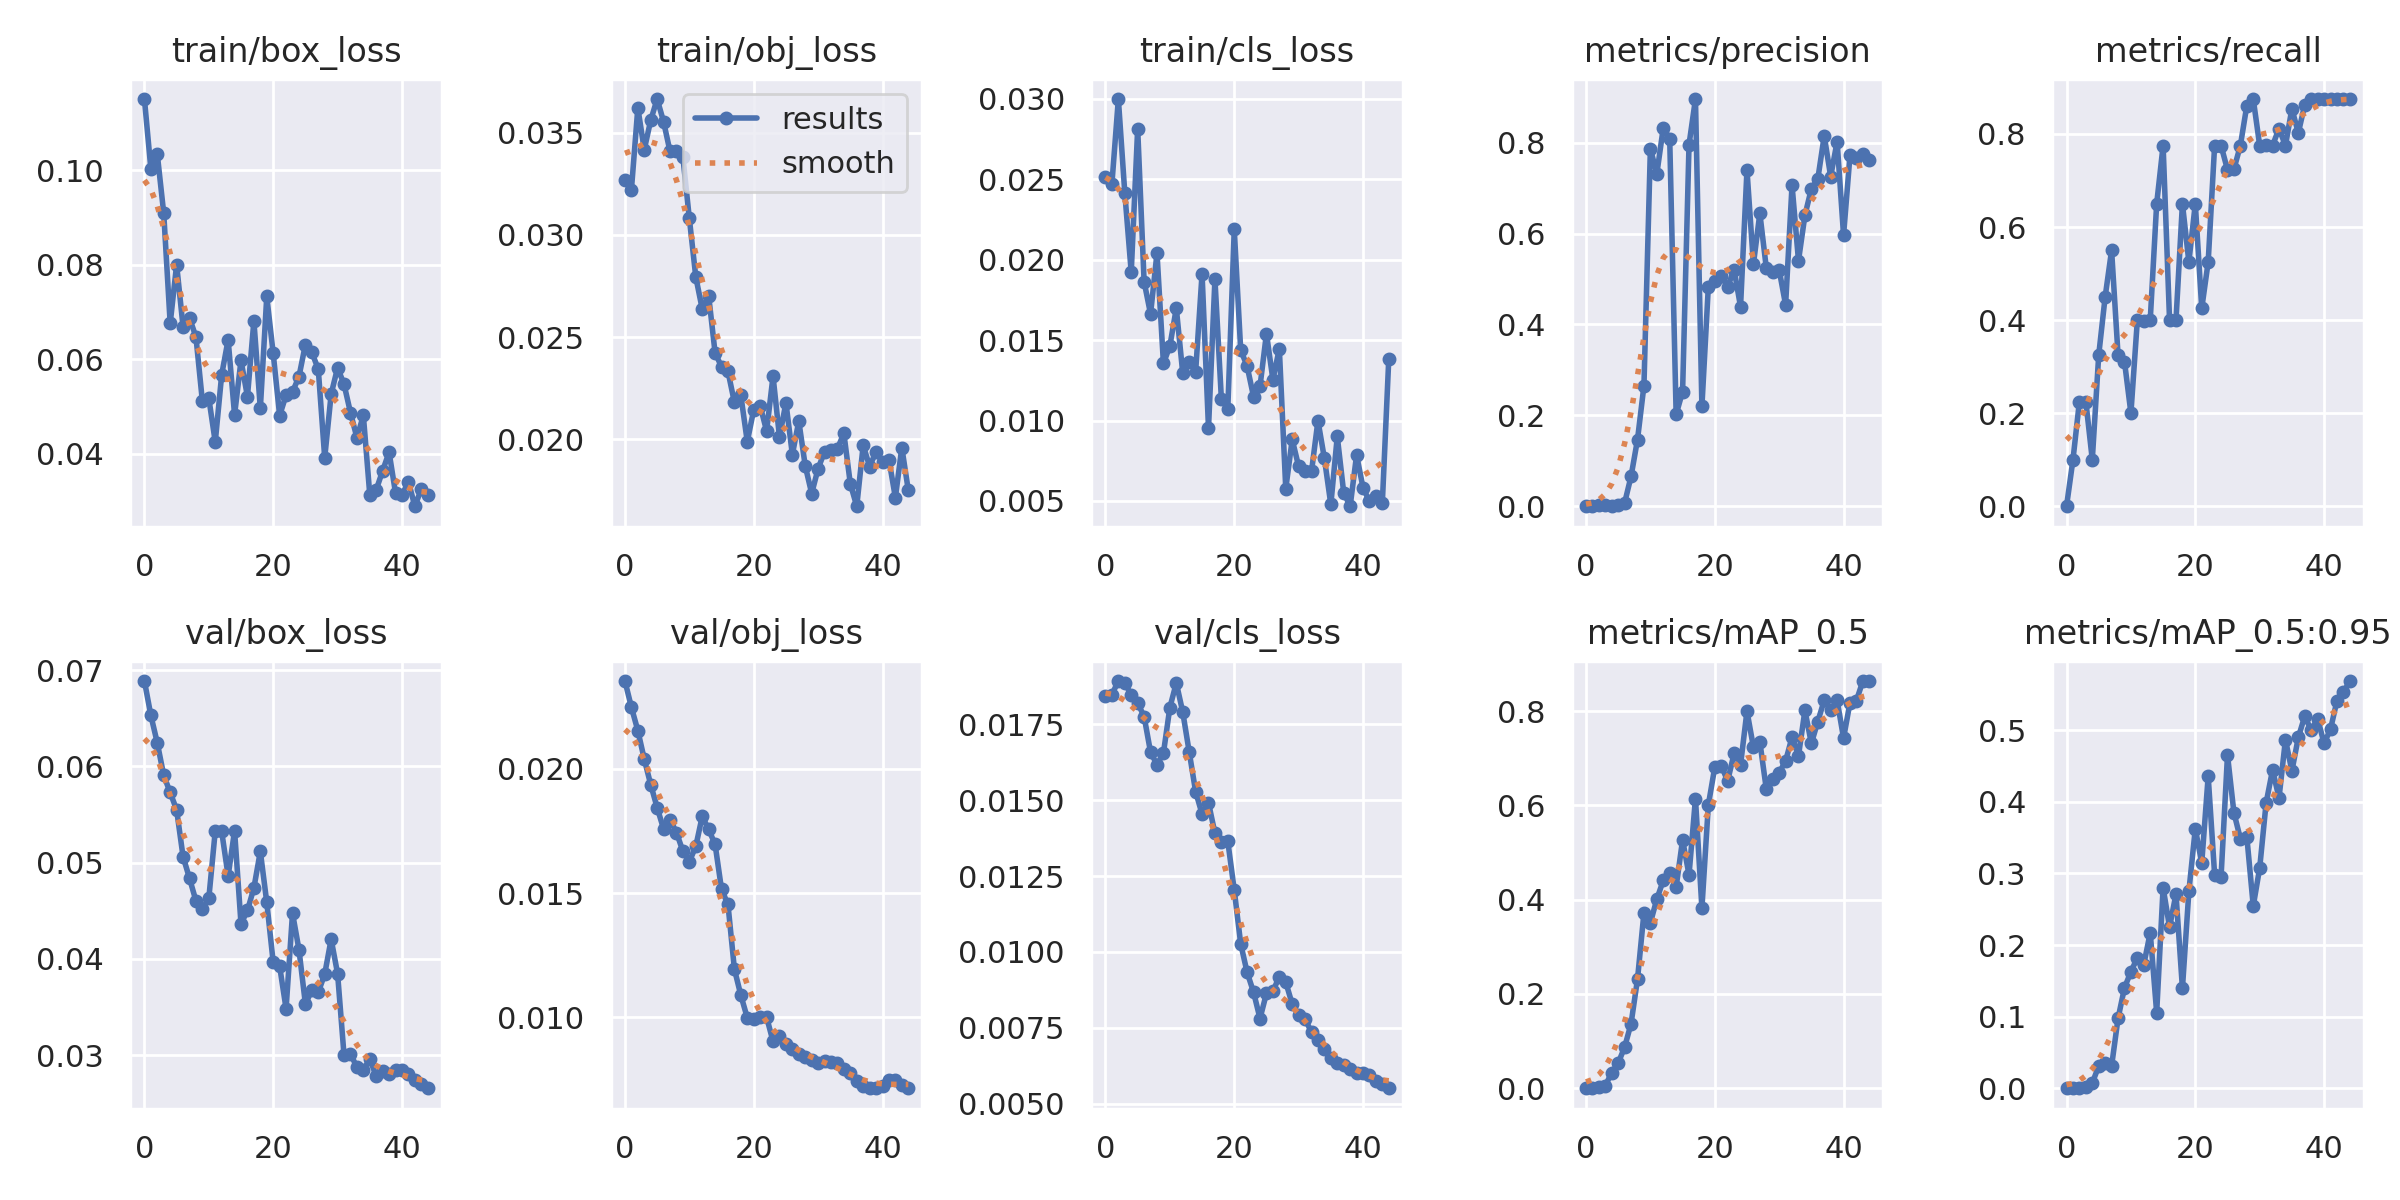

In [64]:
#Construção do gráfico de representação do experimento 2
display(DisplayImage(filename='runs/train/exp2/results.png'))

---
---

Gráficos demonstrativos da evolução do desempenho em relação ao tempo. Queda nos números de perda e aumento nos números de precision e recall.

---
---

In [65]:
#Detecção usando o melhor modelo (exp2 - 45 épocas)
!python detect.py --weights runs/train/exp2/weights/best.pt --img 640 --conf 0.25 --source /content/drive/MyDrive/dataset_fase6/test/images

detect: weights=['runs/train/exp2/weights/best.pt'], source=/content/drive/MyDrive/dataset_fase6/test/images, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-478-g6c66ecd5 Python-3.12.13 torch-2.10.0+cpu CPU

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
image 1/8 /content/drive/MyDrive/dataset_fase6/test/images/tt-1.png: 416x640 1 banana, 327.3ms
image 2/8 /content/drive/MyDrive/dataset_fase6/test/images/tt-2.png: 640x480 2 bananas, 308.9ms
image 3/8 /content/drive/MyDrive/dataset_fase6/test/images/tt-3.png: 448x640 1 banana, 302.3ms
image 4/8 /content/driv

In [66]:
#Listar resultados da detecção
!ls runs/detect

exp


In [67]:
#Listar imagens de teste
!ls runs/detect/exp

tt-1.png  tt-2.png  tt-3.png  tt-4.png	tt-5.png  tt-6.png  tt-7.png  tt-8.png


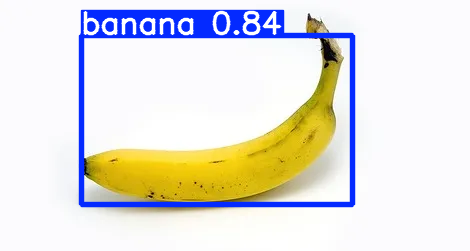

In [71]:
#Exibir uma imagem de exemplo
display(DisplayImage(filename='runs/detect/exp/tt-4.png'))


## 📊 **Resultados com base em um teste feito**

🔹 Treinamento com 30 épocas — desempenho equilibrado com menor capacidade de generalização.

# **Banana:**

- Precision: 0.668
- Recall: 0.504
- mAP50: 0.782

# **Laranja:**

- Precision: 0.543
- Recall: 0.8
- mAP50: 0.703

---

🔹 Treinamento com 45 épocas — maior desempenho geral, indicando maior aprendizado do modelo.

# **Banana:**
      
- Precision: 0.915
- Recall: 0.75
- mAP50: 0.888

# **Laranja:**

- Precision: 0.607
- Recall: 1
- mAP50: 0.84

---
---

## ✅ **Conclusão**
O aumento do número de épocas resultou em uma melhora clara nas métricas de desempenho, especialmente no mAP50. Isso indica que o modelo conseguiu aprender melhor os padrões das imagens com mais tempo de treinamento.

A classe **"banana"** inicialmente apresentou dificuldades, possivelmente devido a:

- Maior variação visual
- Bounding boxes menos precisos
- Presença de ruídos (background capturado)

Após ajustes nas imagens e nas anotações, houve uma melhora significativa nos resultados, evidenciando a importância da qualidade do dataset para o desempenho do modelo.

Apesar das limitações, como o tamanho reduzido do dataset e a baixa diversidade de cenários, o modelo demonstrou evolução consistente ao longo dos treinamentos, apresentando métricas progressivamente mais robustas e confiáveis.


